# Problem 4 - Vectorized KNN

## Interview question

Implement a K-Nearest Neighbor classifier. Given `X_train: [N, D]`, `y_train: [N]`, and `X_test: [M, D]`, predict one label for each test sample. Avoid nested Python loops.

## What is being asked

This is mainly a tensorization and broadcasting problem. The interviewer wants to see pairwise distance computation and clean handling of shapes.

## Clarifying questions

- Which distance metric: L2, L1, cosine?
- What should happen on ties?
- Are labels non-negative integers?
- Is memory an issue for large `N*M`?

## Solution

### Using Numpy and Torch built-in functions

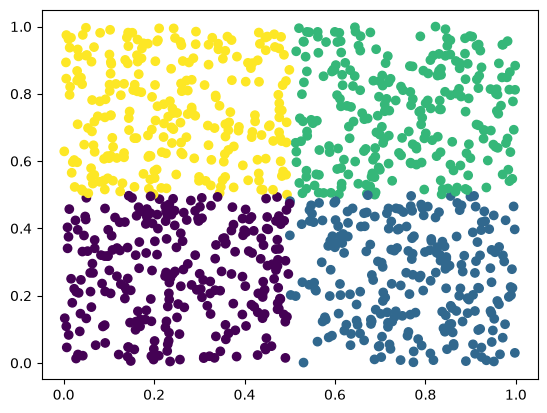

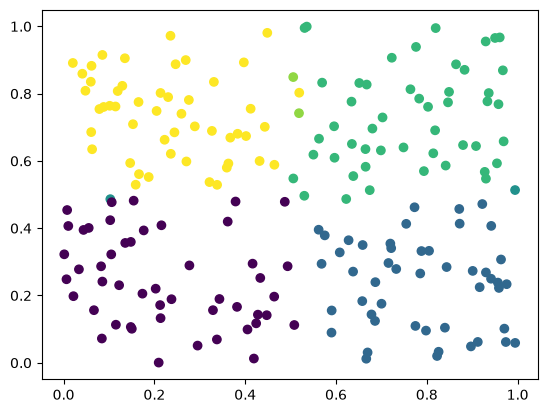

In [5]:
import numpy as np
import torch as th
import matplotlib.pyplot as plt

"""
Inputs X [N, D], Y [N], Xt [M, D]

Outputs Yt = [M]
"""


def fit_knn(X, Y, Xt, K=10):
    N = X.shape[0]
    D = X.shape[1]
    M = Xt.shape[0]

    X = th.tensor(X)
    Y = th.tensor(Y)
    Xt = th.tensor(Xt)

    dist = - th.cdist(Xt, X, p=2) # MxN
    _, topK = th.topk(dist, K) # MxK

    topK_flatten = topK.reshape(M*K)
    topK_Ys = Y[topK_flatten].reshape(M, K)
    Yt = np.median(topK_Ys.numpy(), 1)
    return Yt


if __name__ == "__main__":
    N = 1000
    D = 2
    C = 4
    X = np.random.rand(N, D)
    
    Y = np.zeros((N, C)).astype(np.float16)
    Y[(X[:, 0]<0.5) & (X[:, 1]<0.5)] = [1, 0, 0, 0]
    Y[(X[:, 0]>0.5) & (X[:, 1]<0.5)] = [0, 1, 0, 0]
    Y[(X[:, 0]>0.5) & (X[:, 1]>0.5)] = [0, 0, 1, 0]
    Y[(X[:, 0]<0.5) & (X[:, 1]>0.5)] = [0, 0, 0, 1]
    
    plt.scatter(X[:, 0], X[:, 1], c=np.argmax(Y, 1))
    plt.show()

    Xt = np.random.rand(200, D)
    Yt = fit_knn(X, np.argmax(Y, 1), Xt)

    plt.scatter(Xt[:, 0], Xt[:, 1], c=Yt)
    plt.show()







### From Scratch

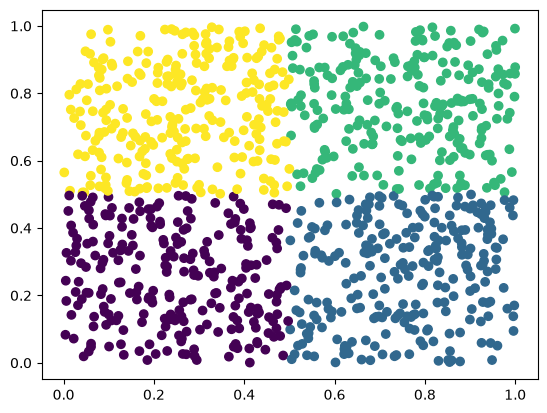

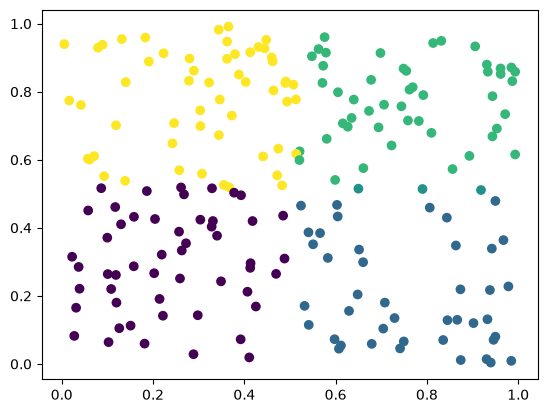

In [ ]:
import numpy as np
import torch as th
import matplotlib.pyplot as plt

"""
Inputs X [N, D], Y [N], Xt [M, D]

Outputs Yt = [M]
"""

def cosine_dist(Xt, X):
    # Xt : MxD 
    # X : NxD
    # Better to do the normalization at the beginning for X
    Xt_n = (Xt - Xt.mean() ) / Xt.std()
    X_n = (X - X.mean() ) / X.std()
    return Xt_n@X_n.T

def l2_dist(Xt, X):
    # Xt : MxD 
    # X : NxD
    Xt_sq = np.sum(Xt**2,1 , keepdims=True)  # M x 1
    X_sq = np.sum(X**2, 1, keepdims=True) # N x 1
    XXt = Xt @ X.T # M x N

    dist = Xt_sq + X_sq.T -2*XXt  
    return dist

def fit_knn(X, Y, Xt, K=10):
    M = Xt.shape[0]

    dist = -cosine_dist(Xt, X) # MxN
    # dist = l2_dist(Xt, X) # MxN
    
    topK = np.argsort(dist, 1) # MxK
    topK = topK[:, :K] # MxK

    topK_Ys = Y[topK]
    Yt = np.median(topK_Ys, 1) # can use np.bincount to count and pick max
    return Yt


if __name__ == "__main__":
    N = 1000
    D = 2
    C = 4
    X = np.random.rand(N, D)
    
    Y = np.zeros((N, C)).astype(np.float16)
    Y[(X[:, 0]<0.5) & (X[:, 1]<0.5)] = [1, 0, 0, 0]
    Y[(X[:, 0]>0.5) & (X[:, 1]<0.5)] = [0, 1, 0, 0]
    Y[(X[:, 0]>0.5) & (X[:, 1]>0.5)] = [0, 0, 1, 0]
    Y[(X[:, 0]<0.5) & (X[:, 1]>0.5)] = [0, 0, 0, 1]
    
    plt.scatter(X[:, 0], X[:, 1], c=np.argmax(Y, 1))
    plt.show()

    Xt = np.random.rand(200, D)
    Yt = fit_knn(X, np.argmax(Y, 1), Xt)

    plt.scatter(Xt[:, 0], Xt[:, 1], c=Yt)
    plt.show()
